# FEATURE ENGINEERING

## Load the data
- Here I load the pickle file that was saved in step1

In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# We load the pickle file so we have the correct data type

df = pd.read_pickle('data_MPG_clean.pkl')

In [3]:
# print 10 sample values

print(df.sample(10))

          mpg  cylinders  displacement  horsepower  weight  acceleration  \
143  26.00000          4            97          78    2300     14.500000   
121  15.00000          8           318         150    3399     11.000000   
180  25.00000          4           121         115    2671     13.500000   
203  29.50000          4            97          71    1825     12.203125   
74   13.00000          8           302         140    4294     16.000000   
114  26.00000          4            98          90    2265     15.500000   
18   27.00000          4            97          88    2130     14.500000   
364  26.59375          8           350         105    3725     19.000000   
207  20.00000          4           130         102    3150     15.703125   
57   24.00000          4           113          95    2278     15.500000   

     model_year  origin  
143          74  europe  
121          73     usa  
180          75  europe  
203          76  europe  
74           72     usa  
114    

In [4]:
# lets see data types and memory usage

print(df.info(memory_usage="deep"))

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   mpg           392 non-null    float16 
 1   cylinders     392 non-null    int8    
 2   displacement  392 non-null    int16   
 3   horsepower    392 non-null    int16   
 4   weight        392 non-null    int16   
 5   acceleration  392 non-null    float16 
 6   model_year    392 non-null    int8    
 7   origin        392 non-null    category
dtypes: category(1), float16(2), int16(3), int8(2)
memory usage: 8.2 KB
None


# Derived Feature: Power-to-Weight Ratio

Instead of raw horsepower and weight, we combine them.

In [5]:
df['power_to_weight'] = df['horsepower'] / df['weight']
print(df[['horsepower', 'weight', 'power_to_weight']].head())

# We can drop HP and weight.

,horsepower,weight,power_to_weight
0,130,3504,0.037100
1,165,3693,0.044679
2,150,3436,0.043655
3,150,3433,0.043694
4,140,3449,0.040591


# Weight Categories (Binning)

Define bins: light / medium / heavy

In [18]:
# step1: 
weight_bins = [0, 2000, 3000, 5000]
weight_labels = ['light', 'medium', 'heavy']

df['weight_category'] = pd.cut(
    df['weight'],
    bins=weight_bins,
    labels=weight_labels
)


# display 10 sample values
print(df[['weight', 'weight_category']].sample(10))

     weight weight_category
367    2605          medium
139    4638           heavy
7      4312           heavy
12     3761           heavy
18     2130          medium
159    4657           heavy
202    3193           heavy
218    1825           light
384    1965           light
101    2904          medium


In [19]:
# stpe2: Distribution Check

df['weight_category'].value_counts()

weight_category
medium    182
heavy     166
light      43
Name: count, dtype: int64

In [20]:
# step3: Display mean MPG by Weight Category

df.groupby('weight_category')['mpg'].mean()

# observ: MPG decreases as we move from light → heavy
# Binning reveals trends clearly

C:\Users\hi\AppData\Local\Temp\ipykernel_14020\3640784986.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('weight_category')['mpg'].mean()


weight_category
light     32.977833
medium    27.280907
heavy     16.834997
Name: mpg, dtype: float32

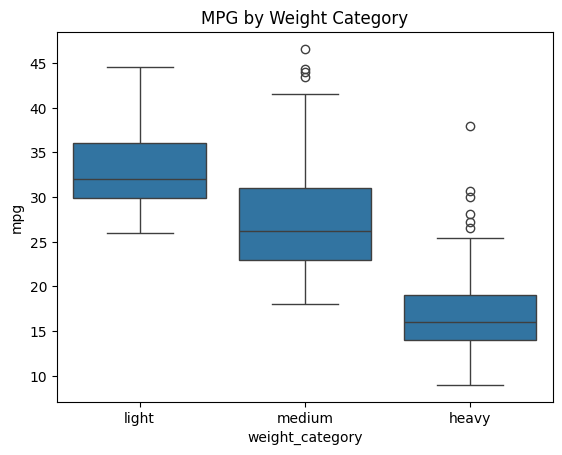

In [21]:
# step4:  Visualization of Binned Features (Weight Category vs MPG)
sns.boxplot(
    data=df,
    x="weight_category",
    y="mpg",
    order=['light', 'medium', 'heavy']
)

plt.title("MPG by Weight Category")
plt.show()


# Horsepower Bins (Quantile-Based Binning)
Equal-frequency bins are often better than fixed bins.

In [13]:
# step1: 
df['horsepower_bin'] = pd.qcut(
    df['horsepower'],
    q=3,
    labels=['low', 'medium', 'high']
)

df[['horsepower', 'horsepower_bin']].sample(10)


,horsepower,horsepower_bin
204,70,low
91,150,high
76,112,high
44,175,high
306,115,high
189,120,high
224,130,high
158,150,high
143,78,low
64,150,high


In [14]:
# step2: display value counts

df['horsepower_bin'].value_counts()

horsepower_bin
medium    144
low       132
high      116
Name: count, dtype: int64

In [15]:
# step3: Display avg MPG by horsepower_bin

df.groupby('horsepower_bin')['mpg'].mean()

C:\Users\hi\AppData\Local\Temp\ipykernel_14020\1697635261.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('horsepower_bin')['mpg'].mean()


horsepower_bin
low       31.153646
medium    22.556967
high      15.778421
Name: mpg, dtype: float32

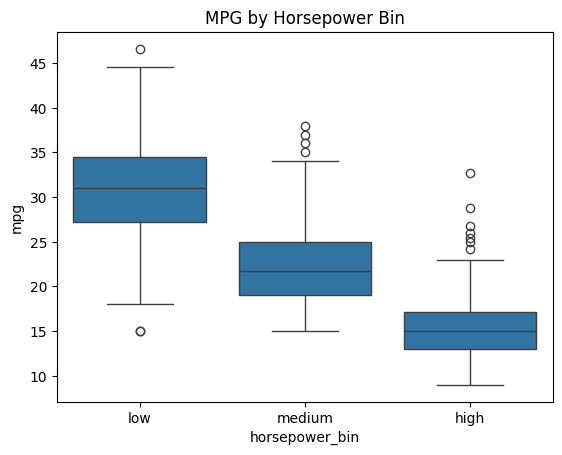

In [17]:
# step4
sns.boxplot(
    data=df,
    x="horsepower_bin",
    y="mpg",
    order=['low', 'medium', 'high']
)

plt.title("MPG by Horsepower Bin")
plt.show()
